In [39]:
import asf_search as asf        # search the ASF catalog
import earthaccess               # authenticate with NASA Earthdata
import h5py                      # read HDF5 files
import numpy as np               # array math
import rioxarray                 # geospatial arrays + GeoTIFF export
import xarray as xr              # labeled arrays
import matplotlib.pyplot as plt  # plotting
from datetime import datetime
import geopandas as gpd
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

print("✓ All imports OK")
print(f"  asf_search version: {asf.__version__}")

auth = earthaccess.login()

✓ All imports OK
  asf_search version: 12.0.7


In [40]:
# ── Helper: parse interferometric pair dates from GUNW scene name ──
def parse_gunw_dates(scene_name):
    """
    GUNW filenames encode the reference and secondary acquisition dates.
    Example: ...20251221T135101...20260102T135101...
             ↑ reference (Dec 21)   ↑ secondary (Jan 2)
    """
    parts = scene_name.split('_')
    timestamps = [p for p in parts if len(p) == 15 and 'T' in p]
    if len(timestamps) >= 4:
        return timestamps[0][:8], timestamps[2][:8]
    return None, None

def temporal_baseline(scene_name):
    ref, sec = parse_gunw_dates(scene_name)
    if ref and sec:
        return abs((datetime.strptime(sec,'%Y%m%d') -
                    datetime.strptime(ref,'%Y%m%d')).days)
    return None

print("Helper functions defined.")

Helper functions defined.


In [41]:
# [Cell 2]
print("Searching ASF catalog for NISAR GUNW data...")

results = asf.search(
    dataset='NISAR',
    processingLevel='GUNW',
    relativeOrbit=77,
    frame=24,
    start='2026-02-07',
    end='2026-02-19'
)

print(f"Found {len(results)} granules matching criteria.")

# Select the first ascending granule with full coverage
granule = next(
    r for r in results 
    if r.properties.get('flightDirection') == 'ASCENDING' 
    and r.properties.get('frameCoverage') == 'Full'
)

scene_name = granule.properties['sceneName']
print(f"Selected Scene: {scene_name}")

Searching ASF catalog for NISAR GUNW data...
Found 2 granules matching criteria.
Selected Scene: NISAR_L2_PR_GUNW_012_077_A_024_013_4000_SH_20260207T124619_20260207T124654_20260219T124619_20260219T124654_P05023_N_F_J_001


In [42]:
granule.properties['url']

'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_PROVISIONAL_V1/NISAR_L2_PR_GUNW_012_077_A_024_013_4000_SH_20260207T124619_20260207T124654_20260219T124619_20260219T124654_P05023_N_F_J_001/NISAR_L2_PR_GUNW_012_077_A_024_013_4000_SH_20260207T124619_20260207T124654_20260219T124619_20260219T124654_P05023_N_F_J_001.h5'

In [43]:
# [Cell 3]
# BASE_URL = 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_BETA_V1'
https_url = granule.properties['url']

# Open HTTPS stream (no data transferred yet)
fs = earthaccess.get_fsspec_https_session()
hf = h5py.File(fs.open(https_url, cache_type='background', block_size=16*1024*1024), 'r')

print(hf)

<HDF5 file "NISAR_L2_PR_GUNW_012_077_A_024_013_4000_SH_20260207T124619_20260207T124654_20260219T124619_20260219T124654_P05023_N_F_J_001.h5>" (mode r)>


In [50]:
BASE_GRIDS = 'science/LSAR/GUNW/grids/frequencyA'
BASE_META  = 'science/LSAR/GUNW/metadata'

# Read coordinate arrays — these are tiny, just 1D arrays
x_80m  = hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/xCoordinates'][:]
y_80m  = hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/yCoordinates'][:]
x_20m  = hf[f'{BASE_GRIDS}/wrappedInterferogram/HH/xCoordinates'][:]
y_20m  = hf[f'{BASE_GRIDS}/wrappedInterferogram/HH/yCoordinates'][:]
x_inc  = hf[f'{BASE_META}/radarGrid/xCoordinates'][:]
y_inc  = hf[f'{BASE_META}/radarGrid/yCoordinates'][:]
epsg   = int(hf[f'{BASE_GRIDS}/unwrappedInterferogram/HH/projection'][()])

print(f"Projection     : EPSG:{epsg}  (UTM — Universal Transverse Mercator)")
print(f"20m grid       : {len(x_20m)} cols × {len(y_20m)} rows")
print(f"Width          : {(x_80m.max()-x_80m.min())/1000:.0f} km")
print(f"Height         : {abs(y_20m.max()-y_20m.min())/1000:.0f} km")
print(f"Easting        : {x_20m.min():.0f} – {x_20m.max():.0f} m")
print(f"Northing       : {y_20m.min():.0f} – {y_20m.max():.0f} m")
print('-')
print(f"80m grid       : {len(x_80m)} cols × {len(y_80m)} rows")
print(f"Width          : {(x_80m.max()-x_80m.min())/1000:.0f} km")
print(f"Height         : {abs(y_80m.max()-y_80m.min())/1000:.0f} km")
print(f"Easting        : {x_80m.min():.0f} – {x_80m.max():.0f} m")
print(f"Northing       : {y_80m.min():.0f} – {y_80m.max():.0f} m")

Projection     : EPSG:32611  (UTM — Universal Transverse Mercator)
20m grid       : 18000 cols × 17784 rows
Width          : 360 km
Height         : 356 km
Easting        : 324010 – 683990 m
Northing       : 4746250 – 5101910 m
-
80m grid       : 4500 cols × 4446 rows
Width          : 360 km
Height         : 356 km
Easting        : 324040 – 683960 m
Northing       : 4746280 – 5101880 m


In [45]:
def print_hdf5_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name} | Shape: {obj.shape} | Dtype: {obj.dtype}")
    else:
        print(f"Group:   {name}")


print("--- HDF5 File Hierarchy ---")
hf.visititems(print_hdf5_structure)

--- HDF5 File Hierarchy ---
Group:   complex64
Group:   science
Group:   science/LSAR
Group:   science/LSAR/GUNW
Group:   science/LSAR/GUNW/grids
Group:   science/LSAR/GUNW/grids/frequencyA
Dataset: science/LSAR/GUNW/grids/frequencyA/centerFrequency | Shape: () | Dtype: float64
Dataset: science/LSAR/GUNW/grids/frequencyA/listOfPolarizations | Shape: (1,) | Dtype: |S2
Group:   science/LSAR/GUNW/grids/frequencyA/pixelOffsets
Group:   science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/alongTrackOffset | Shape: (4446, 4500) | Dtype: float32
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/correlationSurfacePeak | Shape: (4446, 4500) | Dtype: float32
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/projection | Shape: () | Dtype: uint32
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/slantRangeOffset | Shape: (4446, 4500) | Dtype: float32
Dataset: science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/

In [46]:
# Define paths for the requested 80m and 20m layers
paths = {
    'unwrapped_phase_80m': f'{BASE_GRIDS}/unwrappedInterferogram/HH/unwrappedPhase',
    'coherence_80m': f'{BASE_GRIDS}/unwrappedInterferogram/HH/coherenceMagnitude',
    'wrapped_phase_20m': f'{BASE_GRIDS}/wrappedInterferogram/HH/wrappedInterferogram',
    'coherence_20m': f'{BASE_GRIDS}/wrappedInterferogram/HH/coherenceMagnitude'
}

print("Checking RAM footprint before downloading...")
for name, path in paths.items():
    if path in hf:
        print(f'Checking {path}')
        ds = hf[path]
        ram_mb = (ds.size * ds.dtype.itemsize) / 1e6
        print(f"  {name}: {ds.shape} | Expected RAM: {ram_mb:.1f} MB")

Checking RAM footprint before downloading...
Checking science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/unwrappedPhase
  unwrapped_phase_80m: (4446, 4500) | Expected RAM: 80.0 MB
Checking science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/coherenceMagnitude
  coherence_80m: (4446, 4500) | Expected RAM: 80.0 MB
Checking science/LSAR/GUNW/grids/frequencyA/wrappedInterferogram/HH/wrappedInterferogram
  wrapped_phase_20m: (17784, 18000) | Expected RAM: 2560.9 MB
Checking science/LSAR/GUNW/grids/frequencyA/wrappedInterferogram/HH/coherenceMagnitude
  coherence_20m: (17784, 18000) | Expected RAM: 1280.4 MB


In [51]:
def get_clipped_da(ds_path, x_coords, y_coords, name, epsg, clip_geom=None):
    """Reads HDF5 dataset, masks no-data, wraps in DataArray, and optionally clips."""
    ds = hf[ds_path]
    data = ds[:].astype(np.float32)
    
    # Mask fill values and zeros
    fv = ds.attrs.get('_FillValue', None)
    if fv is not None:
        data = np.where(data == fv, np.nan, data)
    data[data == 0] = np.nan
    
    # Create DataArray
    da = xr.DataArray(data, dims=['y', 'x'], coords={'x': x_coords, 'y': y_coords}, name=name)
    da = da.rio.write_crs(f'EPSG:{epsg}').rio.write_nodata(np.nan)
    
    return da.rio.clip(clip_geom, all_touched=True, drop=True) if clip_geom is not None else da

# ── 2. Load and Reproject Bounding Shapefile ──
print("Loading and reprojecting shapefile boundary...")
# Assuming epsg is defined earlier in your notebook (e.g., epsg = 32611)
mores_boundary = gpd.read_file(shapefile_path).to_crs(f'EPSG:{epsg}')
geometries = mores_boundary.geometry

# ── 3. Read and Clip Layers Directly ──
print("Reading and clipping 80m layers...")

unwrapped_80m = get_clipped_da(
    paths['unwrapped_phase_80m'],
    x_80m, y_80m, 'unwrapped_phase', epsg, clip_geom=geometries
)

coherence_80m = get_clipped_da(
    paths['coherence_80m'], 
    x_80m, y_80m, 'coherence', epsg, clip_geom=geometries
)

print("Reading and clipping 20m layers...")

wrapped_20m = get_clipped_da(
    paths['wrapped_phase_20m'], 
    x_20m, y_20m, 'wrapped_phase', epsg, clip_geom=geometries
)

coherence_20m = get_clipped_da(
    paths['coherence_20m'], 
    x_20m, y_20m, 'coherence', epsg, clip_geom=geometries
)

# Incidence angle requires finding the correct height index first
heights = hf[f'{BASE_META}/radarGrid/heightAboveEllipsoid'][:]
gidx = int(np.argmin(np.abs(heights)))
inc_data = hf[f'{BASE_META}/radarGrid/incidenceAngle'][gidx].astype(np.float32)
inc_data[inc_data == 0] = np.nan

da_inc = xr.DataArray(inc_data, dims=['y', 'x'], coords={'x': x_inc, 'y': y_inc}, name='incidence_angle')
da_inc = da_inc.rio.write_crs(f'EPSG:{epsg}').rio.write_nodata(np.nan)
incidence_clip = da_inc.rio.clip(geometries, all_touched=True, drop=True)

hf.close()

# ── 4. Summary ──
print(f"\n✓ Stream closed. Layers clipped to Mores Creek.")
print(f"  Clipped Shape  (Unwrapped): {unwrapped_clip.shape}")
print(f"  Clipped Bounds (Unwrapped): {unwrapped_clip.rio.bounds()}")

print(f"  Clipped Shape  (Wrapped): {unwrapped_clip.shape}")
print(f"  Clipped Bounds (Wrapped): {unwrapped_clip.rio.bounds()}")

clip_ram = (unwrapped_clip.nbytes + coherence_clip.nbytes + incidence_clip.nbytes) / 1e6
print(f"  Clipped RAM   : {clip_ram:.1f} MB")

Loading and reprojecting shapefile boundary...
Reading and clipping 80m layers...
Reading and clipping 20m layers...

✓ Stream closed. Layers clipped to Mores Creek.
  Clipped Shape  (Unwrapped): (106, 99)
  Clipped Bounds (Unwrapped): (601520.0, 4862400.0, 609440.0, 4870880.0)
  Clipped Shape  (Wrapped): (106, 99)
  Clipped Bounds (Wrapped): (601520.0, 4862400.0, 609440.0, 4870880.0)
  Clipped RAM   : 0.1 MB


In [47]:
# def read_and_mask(ds_path):
#     ds = hf[ds_path]
#     data = ds[:].astype(np.float32)
#     fv = ds.attrs.get('_FillValue', None)
#     if fv is not None:
#         data = np.where(data == fv, np.nan, data)
#     data[data == 0] = np.nan
#     return data

# # ── 2. Helper Function to Build and Clip an xarray.Dataset ──
# def get_clipped_dataset(unw_path, coh_path, x_coords, y_coords, epsg, clip_geom=None):
#     """Reads layers, builds a multi-variable xarray Dataset, and clips it."""
    
#     # Read raw arrays
#     unw_data = read_and_mask(unw_path)
#     coh_data = read_and_mask(coh_path)
    
#     # Construct Dataset with both layers
#     ds = xr.Dataset(
#         data_vars={
#             "unwrapped_phase": (["y", "x"], unw_data),
#             "coherence": (["y", "x"], coh_data),
#         },
#         coords={
#             "x": x_coords,
#             "y": y_coords,
#         }
#     )
    
#     # Assign CRS and NoData values to the entire dataset
#     ds = ds.rio.write_crs(f'EPSG:{epsg}')
#     for var in ds.data_vars:
#         ds[var] = ds[var].rio.write_nodata(np.nan)
        
#     # Clip and return
#     return ds.rio.clip(clip_geom, all_touched=True, drop=True) if clip_geom is not None else ds

# # ── 3. Load Shapefile ──
# # Assuming 'epsg' is defined (e.g., 32611)
# mores_boundary = gpd.read_file(shapefile_path).to_crs(f'EPSG:{epsg}')
# geometries = mores_boundary.geometry

# # ── 4. Generate the 20m and 80m Datasets ──
# print("Generating clipped 20m and 80m datasets...")

# # Define your paths (update these based on your specific HDF5 structure)
# path_20m_unw = paths['wrapped_phase_20m']
# path_20m_coh = paths['coherence_20m']

# path_80m_unw = paths['unwrapped_phase_80m']
# path_80m_coh = paths['coherence_80m']

# # Create the 20m Dataset (Assumes x_20m, y_20m are defined)
# granule_20m = get_clipped_dataset(
#     unw_path=path_20m_unw,
#     coh_path=path_20m_coh,
#     x_coords=x_20m,
#     y_coords=y_20m,
#     epsg=epsg,
#     clip_geom=geometries
# )

# # Create the 80m Dataset (Assumes x_80m, y_80m are defined)
# granule_80m = get_clipped_dataset(
#     unw_path=path_80m_unw,
#     coh_path=path_80m_coh,
#     x_coords=x_80m,
#     y_coords=y_80m,
#     epsg=epsg,
#     clip_geom=geometries
# )

# hf.close()

# # ── 5. Summary ──
# print(f"\n✓ Created granule_20m: {granule_20m.unwrapped_phase.shape}")
# print(f"✓ Created granule_80m: {granule_80m.unwrapped_phase.shape}")

Generating clipped 20m and 80m datasets...


ValueError: conflicting sizes for dimension 'x': length 4500 on 'x' and length 18000 on {'y': 'unwrapped_phase', 'x': 'unwrapped_phase'}

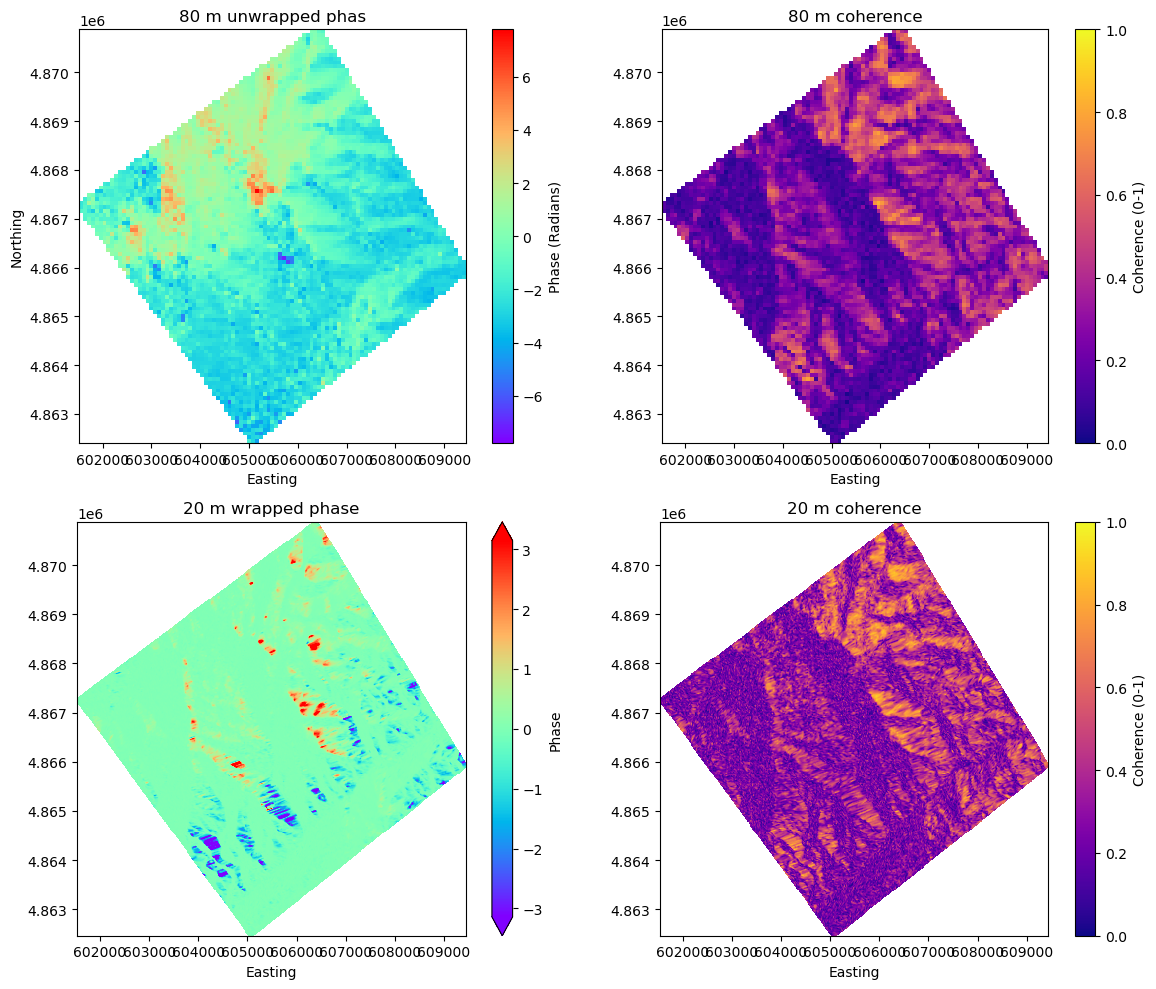

In [57]:
# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# ── 1. Plot Unwrapped Phase ──
# Unwrapped phase represents relative ground displacement (continuous values)
unwrapped_80m.plot(
    ax=axes[0], 
    cmap='rainbow', 
    cbar_kwargs={'label': 'Phase (Radians)'}
)
axes[0].set_title('80 m unwrapped phas')
axes[0].set_aspect('equal') # Maintains proper spatial proportions
axes[0].set_xlabel('Easting')
axes[0].set_ylabel('Northing')

# ── 2. Plot Coherence Magnitude ──
# Coherence ranges from 0 (noise, decorrelation) to 1 (perfect correlation)
coherence_80m.plot(
    ax=axes[1], 
    cmap='plasma', 
    vmin=0, 
    vmax=1, 
    cbar_kwargs={'label': 'Coherence (0-1)'}
)
axes[1].set_title('80 m coherence')
axes[1].set_aspect('equal')
axes[1].set_xlabel('Easting')
axes[1].set_ylabel('') # Hide y-label to avoid redundancy 

wrapped_20m.plot(
    ax=axes[2], 
    cmap='rainbow', 
    vmin=-np.pi, 
    vmax=np.pi,
    cbar_kwargs={'label': 'Phase'}
)
axes[2].set_title('20 m wrapped phase')
axes[2].set_aspect('equal')
axes[2].set_xlabel('Easting')
axes[2].set_ylabel('') # Hide y-label to avoid redundancy 

coherence_20m.plot(
    ax=axes[3], 
    cmap='plasma', 
    vmin=0, 
    vmax=1, 
    cbar_kwargs={'label': 'Coherence (0-1)'}
)
axes[3].set_title('20 m coherence')
axes[3].set_aspect('equal')
axes[3].set_xlabel('Easting')
axes[3].set_ylabel('') # Hide y-label to avoid redundancy 

plt.tight_layout()
plt.show()

In [66]:
coherence_difference = coherence_20m - coherence_80m.rio.reproject_match(coherence_20m)


Text(0, 0.5, '')

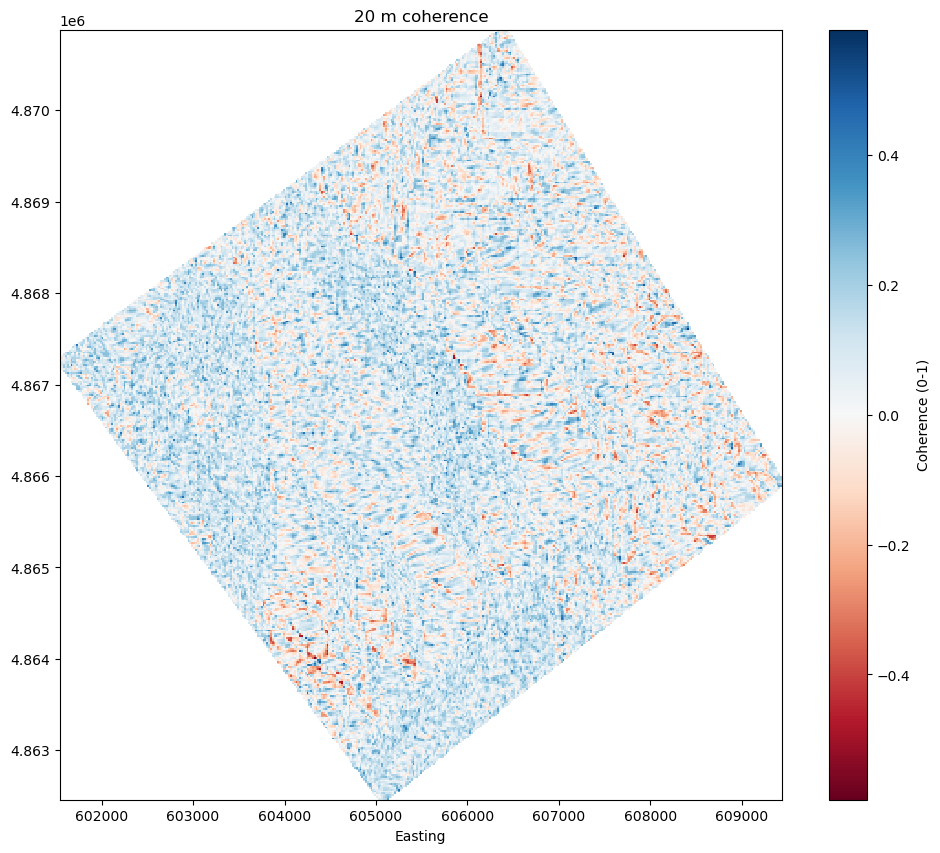

In [70]:
fig, ax = plt.subplots(figsize=(12, 10))

coherence_difference.plot(
    ax=ax, 
    cmap='RdBu', 
    cbar_kwargs={'label': 'Coherence (0-1)'}
)
ax.set_title('20 m coherence')
ax.set_aspect('equal')
ax.set_xlabel('Easting')
ax.set_ylabel('') # Hide y-label to avoid redundancy 